In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
# from IPython.display import Image, display
from tqdm import tqdm
# import external libraries

In [2]:
from JAX_BSSN.evolve import rk4_step
from JAX_BSSN.bssn import (
    BSSNVariables, BSSNParameters, compute_momentum_constraint
)
from JAX_BSSN.tensor_algebra import (
    determinant_3x3_metric, invert_3x3_metric,
    christoffel_symbols_second_kind
)

from JAX_BSSN.derivatives import (
    diff1_field
)

from JAX_BSSN.errors import (
    compute_hamiltonian_constraint
)

from JAX_BSSN.bssn import BSSNVariables, BSSNParameters, compute_ricci
from JAX_BSSN.derivatives import diff1_field
from JAX_BSSN.tensor_algebra import (invert_3x3_metric,
                           christoffel_symbols_second_kind, trace_tensor)


from JAX_BSSN.derivatives import (diff1_field)
from JAX_BSSN.tensor_algebra import (invert_3x3_metric, christoffel_symbols_second_kind,
                           trace_tensor, traceless_part )

This is a demonstration of a gauge wave simulation using the JAX_BSSN code.

This simulation uses harmonic gauge slicing and zero-shift conditions to evolve a 1D gauge wave.

$$
ds^{2} = -H\,dt^{2} + H\,dx^{2} + dy^{2} + dz^{2},
$$

where

$$
H = 1 - A \sin\!\left(\frac{2\pi (x - t)}{d}\right).
$$

The nonzero component of the extrinsic curvature is
$$
K_{xx} = -\frac{\pi A}{d}\,
\frac{\cos\!\left(\frac{2\pi (x - t)}{d}\right)}{\sqrt{1 + A \sin\!\left(\frac{2\pi (x - t)}{d}\right)}},
$$
and
$$
K_{ij} = 0 \quad \text{otherwise.}
$$


I will be using the Bona-Masso slicing condition: $$\partial_{t}\alpha = -\alpha^{2} \gamma^{ij} K_{ij}$$

Resolution Parameters:

- Number of grid points (nx): 50
- Domain length (L): 1.0, x ∈ [-0.5, 0.5]
- Time step (dt): 0.25 * dx

- Amplitude (A): 0.1
- Wavelength (d): 1.0

Uses these definitions to create NamedTuple classes for BSSN evolution variables and parameters.

```python

class BSSNVariables(NamedTuple):
    """Container for BSSN evolution variables."""
    conformal_metric: jnp.ndarray      # γ_ij (3x3 symmetric)
    conformal_factor: jnp.ndarray      # W or φ
    traceless_K: jnp.ndarray          # A_ij (3x3 traceless)
    trace_K: jnp.ndarray              # K (scalar)
    conformal_connection: jnp.ndarray  # Γ^i (3-vector)
    lapse: jnp.ndarray                # α (scalar)
    shift: jnp.ndarray                # β^i (3-vector)


class BSSNParameters(NamedTuple):
    """Parameters for BSSN evolution."""
    eta: float = 2.0          # Damping parameter for Γ^i evolution
    kappa: float = 0.0        # Constraint damping parameter
    nu: float = 0.25          # Kreiss-Oliger dissipation coefficient
    f: float = 1.0            # Multiple of 1+log slicing
    g: float = 0.75           # Gamma driver shift parameter
    dx: float = 0.1           # Grid spacing
    dt: float = 0.001         # Time step



In [16]:
# Simulation parameters ########################################
p = 2 # use to increase resolution
plot_freq = 5 # how often to plot during the simulation
Nt = 1000  # Number of time steps
################################################################

nx = 50*p
L = 1.0  # Domain length
dx = L / nx
x = jnp.linspace(-L/2, L/2, nx, endpoint=False)
dt = 0.25 * dx  # Time step
A = 0.1  # Amplitude of the gauge wave
d = 1.0  # Wavelength of the gauge wave

In [4]:
# initial metric tensor

def H(x, t):
    return 1 - A * jnp.sin((2 * jnp.pi * (x - t)) / d)

alpha = jnp.expand_dims( jnp.sqrt(H(x, 0.0)), axis=(1,2))
beta = jnp.zeros((3, nx, 1, 1))
# lapse and shift variables

g_xx = H(x, 0.0)
g_yy = jnp.ones_like(x)
g_zz = jnp.ones_like(x)
# spatial metric components

In [5]:
conformal_factor = jnp.power(  H(x, 0.0), -1/6 )
# determinant of the spatial metric ^ (-1/6)

gamma = jnp.zeros((3, 3, nx, 1, 1))
gamma = gamma.at[0, 0, :, 0, 0].set(g_xx * jnp.power(conformal_factor, 2))
gamma = gamma.at[1, 1, :, 0, 0].set(g_yy * jnp.power(conformal_factor, 2))
gamma = gamma.at[2, 2, :, 0, 0].set(g_zz * jnp.power(conformal_factor, 2))
# conformal metric tensor

K = jnp.zeros_like(gamma)
K_xx = - (jnp.pi * A / d) * jnp.cos((2 * jnp.pi * (x - 0.0)) / d) / jnp.sqrt(H(x, 0.0))
K = K.at[0, 0, :, 0, 0].set(K_xx)
# extrinsic curvature tensor

inv_gamma = invert_3x3_metric(gamma)
# inverse conformal metric

A_ij = jnp.power(conformal_factor, 2) * traceless_part(K, gamma, inv_gamma)
# traceless part of the extrinsic curvature
K_trace = trace_tensor(K, inv_gamma)
# trace of the extrinsic curvature

derivs = jnp.stack( [diff1_field(gamma, d+2, dx) for d in range(3)], axis=0)
christoffel_2 = christoffel_symbols_second_kind(inv_gamma, derivs)
# compute Christoffel symbols for initial conformal metric
initial_conformal_connection = jnp.einsum('mn..., imn... -> i...', inv_gamma, christoffel_2)
# compute initial conformal connection functions


conformal_factor = jnp.expand_dims(conformal_factor, axis=(1,2))
# reshape conformal factor for later use

In [6]:
vars = BSSNVariables(
    conformal_metric=gamma,
    conformal_factor=conformal_factor,
    traceless_K=A_ij,
    trace_K=K_trace,
    conformal_connection=initial_conformal_connection,
    lapse=alpha,
    shift=beta
)
# initialize BSSN variables

def _finite_stats(arr):
    arr = jnp.asarray(arr)
    finite = jnp.isfinite(arr)
    finite_count = jnp.sum(finite)
    total_count = arr.size
    mean_finite = jnp.sum(jnp.where(finite, arr, 0.0)) / jnp.maximum(finite_count, 1)
    frac_nonfinite = 1.0 - (finite_count / total_count)
    return mean_finite, frac_nonfinite, finite_count, total_count

def _print_var_stats(name, arr):
    mean_finite, frac_nonfinite, finite_count, total_count = _finite_stats(arr)
    print(
        f"{name:22s} mean(finite)={float(mean_finite): .6e} | "
        f"nonfinite={float(frac_nonfinite)*100:6.2f}% "
        f"({int(finite_count)}/{int(total_count)} finite) |"
        f" shape={arr.shape}"
    )

_print_var_stats("conformal_metric", vars.conformal_metric)
_print_var_stats("conformal_factor", vars.conformal_factor)
_print_var_stats("traceless_K", vars.traceless_K)
_print_var_stats("trace_K", vars.trace_K)
_print_var_stats("conformal_connection", vars.conformal_connection)
_print_var_stats("lapse", vars.lapse)
_print_var_stats("shift", vars.shift)
# print initial variable statistics

conformal_metric       mean(finite)= 3.335177e-01 | nonfinite=  0.00% (900/900 finite) | shape=(3, 3, 100, 1, 1)
conformal_factor       mean(finite)= 1.000483e+00 | nonfinite=  0.00% (100/100 finite) | shape=(100, 1, 1)
traceless_K            mean(finite)= 5.722046e-10 | nonfinite=  0.00% (90000/90000 finite) | shape=(3, 3, 100, 1, 100)
trace_K                mean(finite)= 3.141608e-03 | nonfinite=  0.00% (100/100 finite) | shape=(100, 1, 1)
conformal_connection   mean(finite)= 7.947286e-09 | nonfinite=  0.00% (300/300 finite) | shape=(3, 100, 1, 1)
lapse                  mean(finite)= 9.993799e-01 | nonfinite=  0.00% (100/100 finite) | shape=(100, 1, 1)
shift                  mean(finite)= 0.000000e+00 | nonfinite=  0.00% (300/300 finite) | shape=(3, 100, 1, 1)


In [7]:
params = BSSNParameters(
    eta=0.0,          # Damping parameter for Γ^i evolution
    kappa = 0.0,    # momentum damping parameter
    nu = 0.0,        # momentum constraint damping
    # kriess oliger dissipation coefficient
    f=1.0,            # Multiple of 1+log slicing
    g=0.0,           # Gamma driver shift parameter
    dx=dx,           # Grid spacing
    dt=dt         # Time step
)

In [8]:
metric_derivs = jnp.stack( [diff1_field(gamma, d+2, dx) for d in range(3)], axis=0) 
ricci_tensor = compute_ricci(vars, params)
ricci_scalar = trace_tensor(ricci_tensor, inv_gamma)
# compute the ricci scalar from the conformal Ricci tensor

K_squared = jnp.power(vars.trace_K, 2)
A_squared = jnp.einsum('ik...,jl...,ij...,kl...->...', inv_gamma, inv_gamma,
                        A_ij, A_ij)

hamiltonian =  jnp.power(conformal_factor, 2) * ricci_scalar + 2/3 * K_squared - A_squared
# compute the hamiltonian constraint

print( jnp.mean(hamiltonian) )
print( jnp.linalg.norm(hamiltonian) )
# compute the initial hamiltonian constraint violation for comparison

-9.2151815e-05
2.183773


In [9]:
hamiltonian_constraints = []
momentum_constraints = []
gxx_list = []
alpha_list = []

for t in tqdm(range(Nt)):
    vars = rk4_step(vars, params)

    if t % plot_freq == 0:
        hamiltonian_constraints.append(compute_hamiltonian_constraint(vars, params))
        momentum_constraints.append( compute_momentum_constraint( vars, params ) )
        physical_metric = vars.conformal_metric / jnp.power(vars.conformal_factor, 2)
        gxx_list.append( physical_metric[0,0,:,0,0] )
        alpha_list.append( vars.lapse[:,0,0] )
        # store data for plotting

100%|██████████| 1000/1000 [00:50<00:00, 19.70it/s]


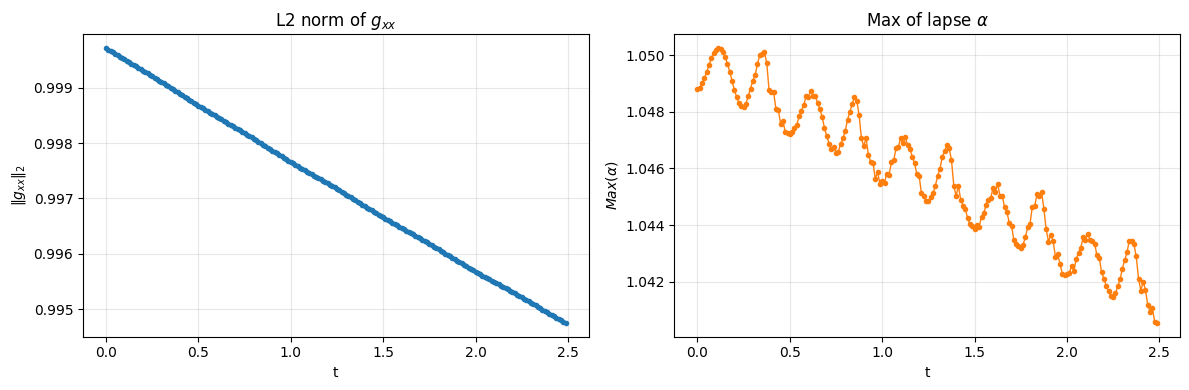

In [10]:
# L2 norm of g_xx (conformal_metric[0,0]) vs time
gxx_hist = jnp.stack(gxx_list, axis=0)      # (n_snaps, nx)
alpha_hist = jnp.stack(alpha_list, axis=0)  # (n_snaps, nx)

gxx_l2 = jnp.sqrt(jnp.mean(gxx_hist**2, axis=1))  # L2 norm of g_xx
alpha_max = jnp.max(jnp.abs(alpha_hist), axis=1)  # (n_snaps,)

# Guard against any length mismatches
n = int(jnp.minimum(gxx_l2.shape[0], alpha_max.shape[0]))
times = jnp.arange(n) * (plot_freq * dt)

gxx_l2 = gxx_l2[:n]
alpha_max = alpha_max[:n]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(times, gxx_l2, marker=".", linewidth=1)
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$\|g_{xx}\|_2$")
axes[0].set_title(r"L2 norm of $g_{xx}$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, alpha_max, marker=".", linewidth=1, color="C1")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$ Max(\alpha)$")
axes[1].set_title(r"Max of lapse $\alpha$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

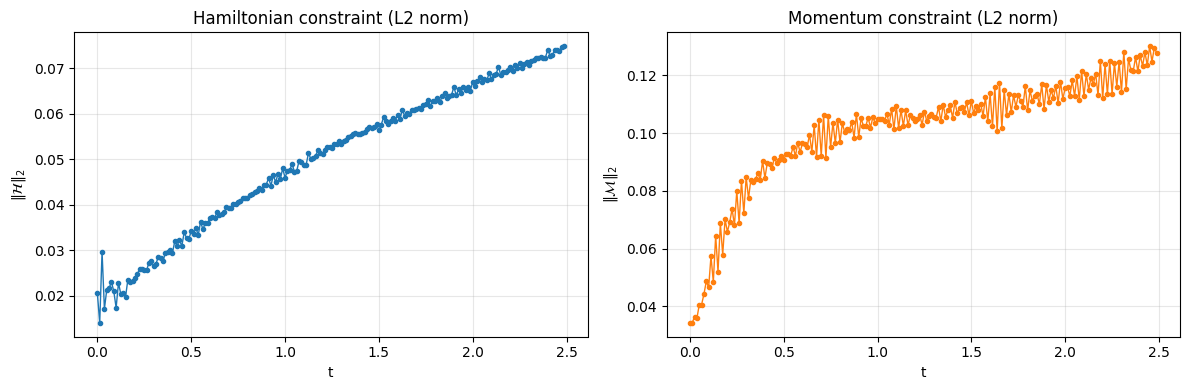

In [11]:
# Stack constraints history (n_snaps, ...)
ham_hist = jnp.stack(hamiltonian_constraints, axis=0)
mom_hist = jnp.stack(momentum_constraints, axis=0)

# L2 norms per snapshot
ham_l2 = jnp.sqrt(jnp.mean(ham_hist.reshape((ham_hist.shape[0], -1))**2, axis=1))
mom_l2 = jnp.sqrt(jnp.mean(mom_hist.reshape((mom_hist.shape[0], -1))**2, axis=1))

# Time array (guard against any length mismatches)
n = int(jnp.minimum(ham_l2.shape[0], mom_l2.shape[0]))
times_c = jnp.arange(n) * (plot_freq * dt)

ham_l2 = ham_l2[:n]
mom_l2 = mom_l2[:n]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(times_c, ham_l2, marker=".", linewidth=1)
axes[0].set_title("Hamiltonian constraint (L2 norm)")
axes[0].set_xlabel("t")
axes[0].set_ylabel(r"$\|\mathcal{H}\|_2$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_c, mom_l2, marker=".", linewidth=1, color="C1")
axes[1].set_title("Momentum constraint (L2 norm)")
axes[1].set_xlabel("t")
axes[1].set_ylabel(r"$\|\mathcal{M}\|_2$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(200, 100) (200, 100)


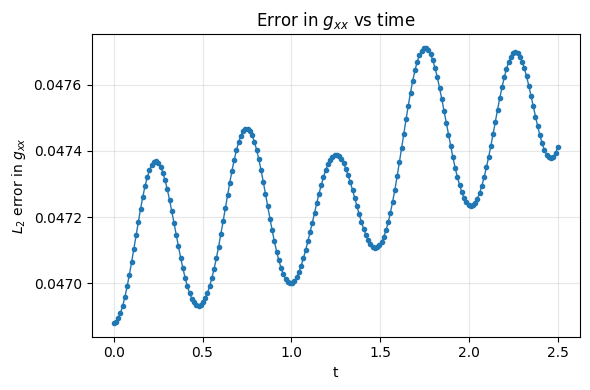

In [22]:
t_ = dt * (1 + jnp.arange(gxx_hist.shape[0]) * plot_freq)  # Snapshot times
gxx_analytic = jax.vmap(lambda t: H(x, t))(t_)  # (Nt, nx)
gxx_numeric = gxx_hist  # (Nt, nx)
print(gxx_analytic.shape, gxx_numeric.shape)

error = gxx_numeric - gxx_analytic
error_l2 = jnp.sqrt(jnp.mean(error**2, axis=1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_, error_l2, marker=".", linewidth=1)
ax.set_xlabel("t")
ax.set_ylabel(r"$L_2$ error in $g_{xx}$")
ax.set_title(r"Error in $g_{xx}$ vs time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
